In [1]:
import mne, os, glob, pickle
import numpy as np
import pandas as pd
import mne_rsa as rsa
from mne.minimum_norm import apply_inverse_epochs
from scipy.spatial.distance import cosine
from gensim import downloader
import matplotlib

#import seaborn as sns fucked up with the env so no longer compatible on lab computer
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Set up

In [2]:
expt = 'SemRep'
main_dir = f'/Volumes/Server/SHARED/Methods meetings/2025_Meetings/RSA' # dataset directory
meg_dir = os.path.join(main_dir, 'meg')
mri_dir = os.path.join(main_dir, 'mri')
os.chdir(main_dir)


In [3]:
subj = 'R1439'
hemis = ['lh', 'rh']
part = '1'

# custom color map for plotting
colors = ["#A09BE7", "#E0D2EF", "#DCE7FA", "#FFD791", "#F7C497", "#F4753E", "#F5646D","#E11466"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", colors)

# Analysis 

## Get single trial stcs

First load in your preprocessed epochs

In [4]:
cleandata = mne.read_epochs(os.path.join(meg_dir,subj,'preproc',f'SemRep_{subj}_final_part1-epo.fif'), preload=True)

Reading /Volumes/Server/SHARED/Methods meetings/2025_Meetings/RSA/meg/R1439/preproc/SemRep_R1439_final_part1-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     850.00 ms
        0 CTF compensation matrices available
Adding metadata with 14 columns
Replacing existing metadata with 14 columns
467 matching events found
No baseline correction applied
0 projection items activated


We will resample the data to make the computations faster as well as cropping it to focus on a specific time window

In [ ]:
cleandata.resample(sfreq=500)
cleandata.crop(0,0.6)

Number of events,467
Events,hom: 163pol: 149unam: 155
Time range,0.000 – 0.600 s
Baseline,-0.200 – 0.850 s


RSA is usually a single-trial analysis. We'll be conducting a searchlight over time points and vertices so we need single-trial stcs...

In [5]:
def make_single_trials(subj, data):
    '''
    Script that creates single trial stcs
    '''
    cov_fname = f'meg/{subj}/source/{subj}_part1-cov.fif'
    fwd_fname = f'meg/{subj}/source/{subj}_part1-fwd.fif'
    
    fwd = mne.read_forward_solution(fwd_fname)
    cov = mne.read_cov(cov_fname)
    print('\n Forward solution and covariance matrix loaded...')
    
    fixed = False
    SNR = 2
    
    info = data.info
        
    inv = mne.minimum_norm.make_inverse_operator(info, fwd, cov, depth=0.8, loose=0.2, fixed=fixed) 
    print('\n Inverse solution created...')
    
    lambda2 = 1.0 / SNR ** 2.0
    
    sing_trstcs= apply_inverse_epochs(data,inv,lambda2, verbose=False,method="dSPM")

    return inv, sing_trstcs

In [6]:
inv, sing_trstcs = make_single_trials(subj, cleandata) # make the single trial stcs

Reading forward solution from /Volumes/Server/SHARED/Methods meetings/2025_Meetings/RSA/meg/R1439/source/R1439_part1-fwd.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523) not available
    Read MEG forward solution (5124 sources, 157 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    157 x 157 full covariance (kind = 1) found.

 Forward solution and covariance matrix loaded...
Converting forward solution to surface orientation
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 157 channels.
    157

## Create RDMs (representational dissimilarity models)

The version of RSA we are demo-ing is one that compares both theoretical and computational models to neural activity. In order to do this, we need to create theoretical models that compute distances between each trial based on our variables of interest. For this, we need to use the logfile to gather information about each trial and get the additional information in the order in which it was presented.

In [12]:
df = cleandata.metadata
df

,participant,trialnum,TW,repetition,POS,context,semantic type,task stim,answer,correct,reaction_time,blockID,triggers,Unnamed: 13
0,R1439,1,rides,1,noun,Null,U,no task,no task,no task,no task,0,"('ch160', 'ch163')",None
1,R1439,2,slips,1,noun,Min,H,no task,no task,no task,no task,0,"('ch162', 'ch164')",None
2,R1439,3,spells,1,noun,Emb,H,no task,no task,no task,no task,0,"('ch162', 'ch165')",None
3,R1439,4,slips,2,noun,Min,H,no task,no task,no task,no task,0,"('ch162', 'ch164')",None
4,R1439,5,slips,2,noun,Emb,H,no task,no task,no task,no task,0,"('ch162', 'ch165')",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,R1439,500,runs,1,noun,Min,H,no task,no task,no task,no task,5,"('ch162', 'ch164')",None
500,R1439,501,travels,1,noun,Null,U,no task,no task,no task,no task,5,"('ch160', 'ch163')",None
501,R1439,502,spells,2,noun,Null,H,no task,no task,no task,no task,5,"('ch162', 'ch163')",None
502,R1439,503,spies,1,noun,Null,U,no task,no task,no task,no task,5,"('ch160', 'ch163')",None


We will be computing three different models:
- a basic composition model
- a static embedding model
- a basic wordform model

There is some additional information we need to add to our logfile first. 

In [8]:
def add_exp_logs(main_dir, df):
    expdata = pd.read_csv(main_dir+ '/Exp_stim.csv', sep=",", lineterminator='\n') 
    expdata = expdata.rename(columns={'tw':'TW', 'stim':'stimulus', 'pos':'POS', 'sem_type':'semantic type'})
    info = expdata[['TW', 'repetition', 'context', 'stimulus', 'POS','semantic type', 'discourse']] 
    newmeta = df.merge(info) # merge the log file with the larger stim file
    newmeta = newmeta.drop(columns=['triggers', 'Unnamed: 13','task stim', 'answer', 'correct', 'reaction_time'])
    return newmeta

In [10]:
meta = add_exp_logs(main_dir, df)
meta

,participant,trialnum,TW,repetition,POS,context,semantic type,blockID,stimulus,discourse
0,R1439,1,rides,1,noun,Null,U,0,rides,darrell is on a road trip
1,R1439,2,slips,1,noun,Min,H,0,her slips,belle gives hall passes
2,R1439,3,spells,1,noun,Emb,H,0,sabina is constantly practicing her spells,the students have magic finals
3,R1439,4,slips,2,noun,Min,H,0,her slips,calla is planning a field trip
4,R1439,5,slips,2,noun,Emb,H,0,she keeps on forgetting her slips,fatou needs permission for a trip
...,...,...,...,...,...,...,...,...,...,...
462,R1439,500,runs,1,noun,Min,H,5,her runs,rosine started training
463,R1439,501,travels,1,noun,Null,U,5,travels,i planned a trip
464,R1439,502,spells,2,noun,Null,H,5,spells,john can levitate
465,R1439,503,spies,1,noun,Null,U,5,spies,martin joined the fbi


In [9]:
def create_meta_for_word2vec(df):
    '''
    this function is specifically for the word2vec analysis
    main dir = directory where the csv file is
    cleandata = subject's loaded meg data
    '''
    word_vectors = downloader.load('word2vec-google-news-300')
    
    df['w2v']= np.array(df['TW'].map(lambda x: word_vectors.get_vector(x)))
    #df.sort_values(by=['TW','POS'])
    return df

In [ ]:
newmeta = create_meta_for_word2vec(meta)
newmeta

,participant,trialnum,TW,repetition,POS,context,semantic type,task stim,answer,correct,reaction_time,blockID,triggers,Unnamed: 13,w2v
0,R1439,1,rides,1,noun,Null,U,no task,no task,no task,no task,0,"('ch160', 'ch163')",None,"[0.09667969, -0.0390625, -0.09277344, 0.146484..."
1,R1439,2,slips,1,noun,Min,H,no task,no task,no task,no task,0,"('ch162', 'ch164')",None,"[-0.14941406, 0.03564453, -0.2578125, 0.045898..."
2,R1439,3,spells,1,noun,Emb,H,no task,no task,no task,no task,0,"('ch162', 'ch165')",None,"[0.14160156, 0.25390625, -0.32226562, -0.14355..."
3,R1439,4,slips,2,noun,Min,H,no task,no task,no task,no task,0,"('ch162', 'ch164')",None,"[-0.14941406, 0.03564453, -0.2578125, 0.045898..."
4,R1439,5,slips,2,noun,Emb,H,no task,no task,no task,no task,0,"('ch162', 'ch165')",None,"[-0.14941406, 0.03564453, -0.2578125, 0.045898..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,R1439,500,runs,1,noun,Min,H,no task,no task,no task,no task,5,"('ch162', 'ch164')",None,"[-0.08642578, 0.1328125, -0.09472656, 0.042480..."
500,R1439,501,travels,1,noun,Null,U,no task,no task,no task,no task,5,"('ch160', 'ch163')",None,"[0.18554688, 0.4453125, -0.078125, -0.10058594..."
501,R1439,502,spells,2,noun,Null,H,no task,no task,no task,no task,5,"('ch162', 'ch163')",None,"[0.14160156, 0.25390625, -0.32226562, -0.14355..."
502,R1439,503,spies,1,noun,Null,U,no task,no task,no task,no task,5,"('ch160', 'ch163')",None,"[0.02746582, 0.08935547, 0.23339844, 0.03125, ..."


Now we have all the information we need to compute our models!

### Helper functions

In [10]:
def composition_model(event_id_1,event_id_2):
    if event_id_1 == 'Min' and event_id_2== 'Emb':
            return 0
    if event_id_1 == 'Emb' and event_id_2== 'Min':
            return 0
    if np.array_equal(event_id_1,event_id_2) == True:
        return 0        
    else:
        return 1
    
def sense_similarity(word1,word2):
    '''
    Function used to compute the distance for a number of one-hot models
    word1: np.array of dtype <U16 or other character dtypes. Cannot be object
    word2: same as word1
    Does a one-hot encoding for all of the senses in the stimuli. 
    '''
    if np.array_equal(word1,word2) == True:
        return 0
    else:
        return 1
    

def create_word2vec_rdm(df):
    metadata = create_meta_for_word2vec(df)
    wordvectors = np.stack(metadata['w2v'].values)
    w2vrdm  = rsa.compute_dsm(wordvectors, metric='cosine')
    return w2vrdm


def create_subj_rdms(meta):
    '''
    Function for one-hot models
    Creates the rdms for wordform model and composition model
    meta is the modified info dataframe for each session
    '''
    # select the data of interest
    wordforms = meta[['TW']].to_numpy(dtype='<U16')
    context = meta[['context']].to_numpy(dtype='<U16')
    
    # compute the rdms
    comprdm = rsa.compute_dsm(context, metric=composition_model)
    wordformrdm = rsa.compute_dsm(wordforms, metric=sense_similarity)

    rdms = [comprdm,wordformrdm]
    
    return rdms

Normally all of this work is collapsed inside of helper functions like the ones above...

In [13]:
meta = add_exp_logs(main_dir, df)

w2vrdm = create_word2vec_rdm(meta)
rdms = create_subj_rdms(meta)
rdms.append(w2vrdm)

AttributeError: module 'mne_rsa' has no attribute 'compute_rdm'

Let's plot our models to see what they look like:

In [ ]:
def plot_rdms(rdms, names, cmap):
    matplotlib.rcParams.update({'font.size': 12})
    matplotlib.rcParams["font.family"] = "Gill Sans"
    fig = rsa.plot_rdms(rdms, names= names, cmap = cmap)
    fig.suptitle('Theoretical dissimilarity models', size=18)
    fig.set_size_inches(6, 3)
    cbar = fig.gca().images[-1].colorbar # get the colorbar from the last axis
    plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
    cbar.set_ticks([0, 1], labels = ['Minimal dissimilarity','Maximal dissimilarity'])

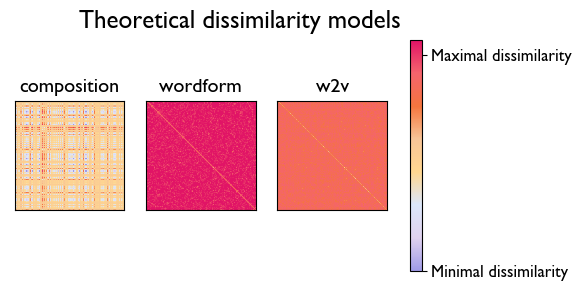

In [44]:
plot_rdms(rdms, ['composition', 'wordform', 'w2v'], cmap1)

These plots make more sense when we have sorted our stim according to relevant criteria like words or context! Plotting the sorted stim is a great way to double check your models and custom functions are doing what they're supposed to...

In [45]:
def plot_simple_models():
    expdata = pd.read_csv(main_dir+ '/Exp_stim.csv', sep=",", lineterminator='\n') 
    expdata = expdata.rename(columns={'tw':'TW', 'stim':'stimulus', 'pos':'POS', 'sem_type':'semantic type'})
    plottable = expdata.sort_values(by=['semantic type', 'context'],  ascending = False) # for simple easy plots 
    plottable = plottable[plottable['TW'].str.contains("dreams|flies|dates", regex=True)]
    
    simple = create_subj_rdms(plottable)
    simple.append(create_word2vec_rdm(plottable))

    plot_rdms(simple, ['composition', 'wordform', 'w2v'], cmap1)
    
    plt.show()

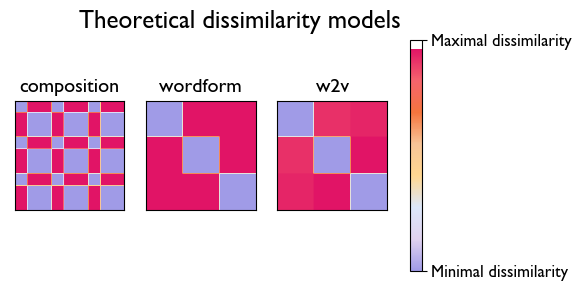

In [46]:
plot_simple_models()

When running multiple models, best practice is to correlate them to make sure they aren't measuring the same thing. 

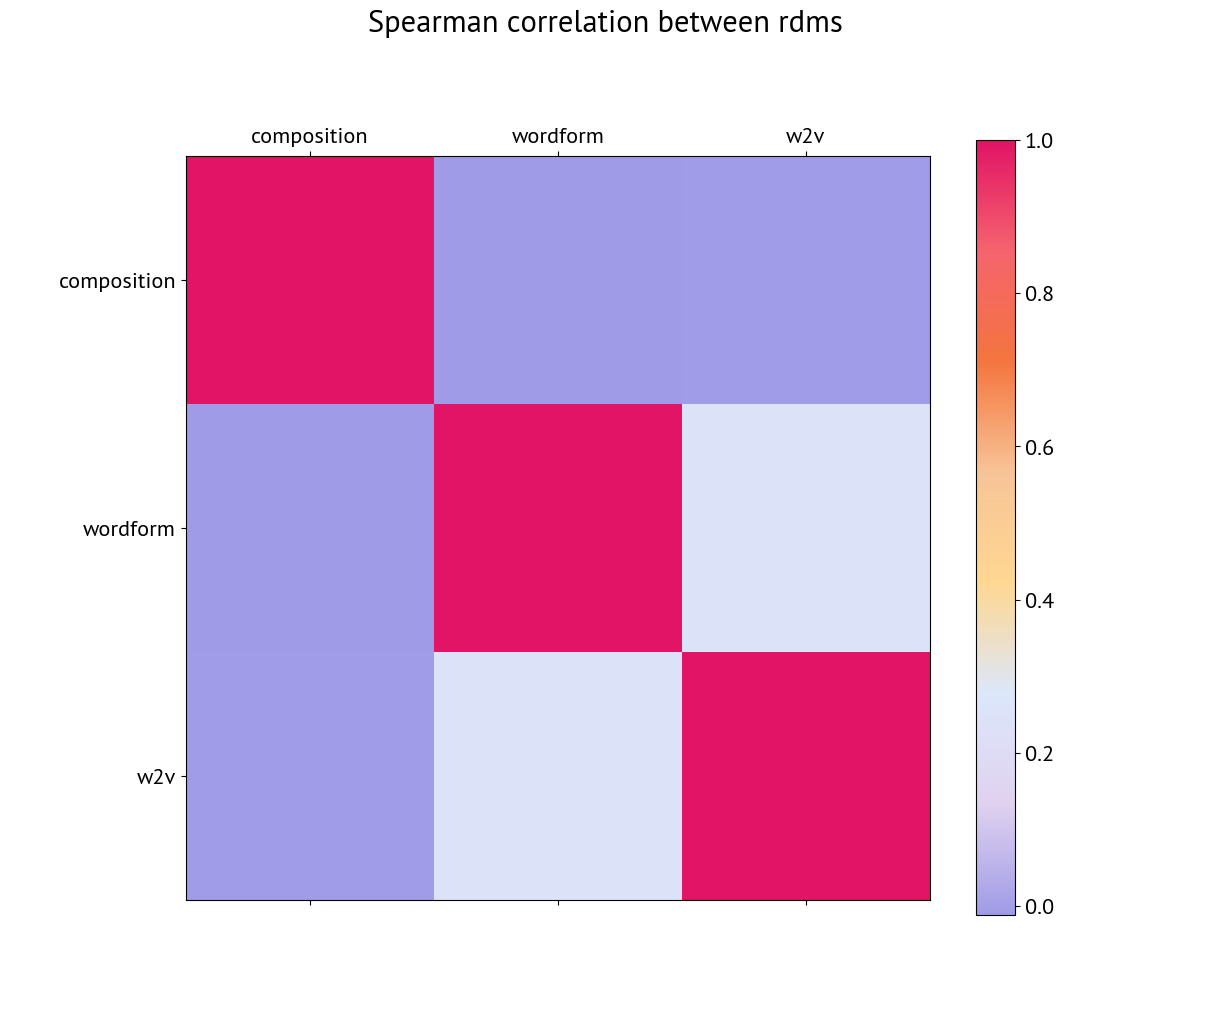

In [49]:
modelcomp = rsa.rsa(rdms, rdms, metric='spearman')

# plot the correlations
matplotlib.rcParams.update({'font.size': 16})
matplotlib.rcParams["font.family"] = "PT Sans"

fig, ax = plt.subplots(figsize = (6,6))
ax.axis('off')
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
plt.matshow(modelcomp, cmap= cmap1, fignum=1)
plt.colorbar()
plt.xticks(range(len(['composition', 'wordform', 'w2v'])), ['composition', 'wordform', 'w2v'], fontsize=16)
plt.yticks(range(len(['composition', 'wordform', 'w2v'])), ['composition', 'wordform', 'w2v'])
plt.suptitle('Spearman correlation between rdms', size=22)
fig.set_constrained_layout('constrained')

plt.show()

## Analysis

Now we can move onto the actual analysis! We'll be using a library that does all of the complicated sampling and searchlighting for us
The default metric is spearman correlation for comparing the MEG data to the models

In [18]:
subjrsa = rsa.rsa_stcs(
    sing_trstcs,                    # The source localized epochs
    rdms,                           # The model DSM(s) we constructed above
    src=inv['src'],                 # The inverse operator has our source space
    stc_rdm_metric ='correlation',  # Metric to compute the MEG DSMs      
    spatial_radius=0.02,            # Spatial radius of the searchlight patch; in meters
    temporal_radius=0.02,           # Temporal radius of the searchlight path; in seconds
    tmin=0, tmax=0.6,               # To save time, only analyze this time interval
    n_jobs=-1,                      # Only use one CPU core. Increase this for more speed.
    verbose=True)

resfname = f'/rsaresults{subj}_part1.pickle'
with open(main_dir + resfname, 'wb') as file:
        pickle.dump(subjrsa,file)

Performing RSA between SourceEstimates and 3 model RDM(s)
    Spatial radius: 2 meters
    Using 5124 vertices
    Temporal radius: 50 samples
    Time interval: 0.2-0.3 seconds
    Number of searchlight patches: 128100




  0%|                                                                                                    | 0/128100 [00:00<?, ?patch/s]

Creating spatio-temporal searchlight patches




  0%|                                                                                           | 24/128100 [00:00<34:00, 62.78patch/s]

  0%|                                                                                           | 24/128100 [00:18<34:00, 62.78patch/s]

  0%|                                                                                        | 48/128100 [01:28<77:06:24,  2.17s/patch]

KeyboardInterrupt: 

In [5]:
def plotrsares(subj,results, model_name, mri_dir, hemi=None, tmin=None, tmax=None, views = ['lat','med']):
    if hemi == None:
        hemi = 'split'
    brain = results.plot(subj, title = f'{model_name}',subjects_dir=mri_dir, surface = 'smoothwm', cortex = 'low_contrast', background='white', hemi = hemi,  views= views)
    return brain

I've loaded data from a previous analysis run so that we can easily plot it and see what it looks like!

In [6]:
resfname = f'/w2vresults_{subj}_part1.pickle'

with open('/Volumes/Server/SHARED/Methods meetings/2025_Meetings/RSA/w2vresults_R1439_part1.pickle', 'rb') as file:
    subjrsa = pickle.load(file)

for hemi in hemis:
    brain = plotrsares(subj,subjrsa,'w2v', mri_dir, hemi= hemi)
    brain.add_annotation('aparc',alpha=0.35, color= 'lightskyblue')

Using pyvistaqt 3d backend.
Using control points [0.00837815 0.00937952 0.01658034]


qt.qpa.fonts: Populating font family aliases took 284 ms. Replace uses of missing font family "Menlo" with one that exists to avoid this cost. 


Using control points [0.00837815 0.00937952 0.01658034]
